# Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import cupy as cp
import seaborn as sns
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB



In [6]:
data_dir='/data/raw/'
session='M061_2025_03_06_14_00'

In [5]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [6]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]

FORE_KEYWORDS = [
    "wrist",
    "paw",
    "elbow",
]

HIND_KEYWORDS = [
    "foot",
    "ankle",
    "knee",
]


def get_limb(forelimb: bool, laterality: str):
    if forelimb:
        body_parts = FORE_KEYWORDS
    else:
        body_parts = HIND_KEYWORDS

    bhv_fields = [
        field
        for field in ALL_BHV_FIELDS
        if (laterality in field) and any(body_part in field for body_part in body_parts)
    ]
    return bhv_fields

feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


In [12]:
df__ = dt.add_pca_df(df_.iloc[1:])

In [ ]:
# compute_perturbation_metric is defined in tools/kinematics/disturb_score.py
# and exported via tools.kinematics


In [53]:
df = kin.compute_perturbation_metric(df__, bhv_fields=Params.oscillating_key_points)

# Select trials and drop nans
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr_dropped = kin.drop_immobile_trials(df_tr, min_immobile_bins=5)

# df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10, event_onset=(100, 500))
mask = df_tr["disturb_score"].apply(
    lambda x: isinstance(x, np.ndarray) and not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

df_tr['disturb_mean'] = df_tr['disturb_score'].apply(lambda a: np.mean(a))
df_tr['disturb_sum'] = df_tr['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

# # Add instantaneous phase
disturbances = np.sum(np.stack(df_tr.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 40 trials
Otsu immobility threshold: 2.9536
Dropped 48 of 333 rows (14.41%).


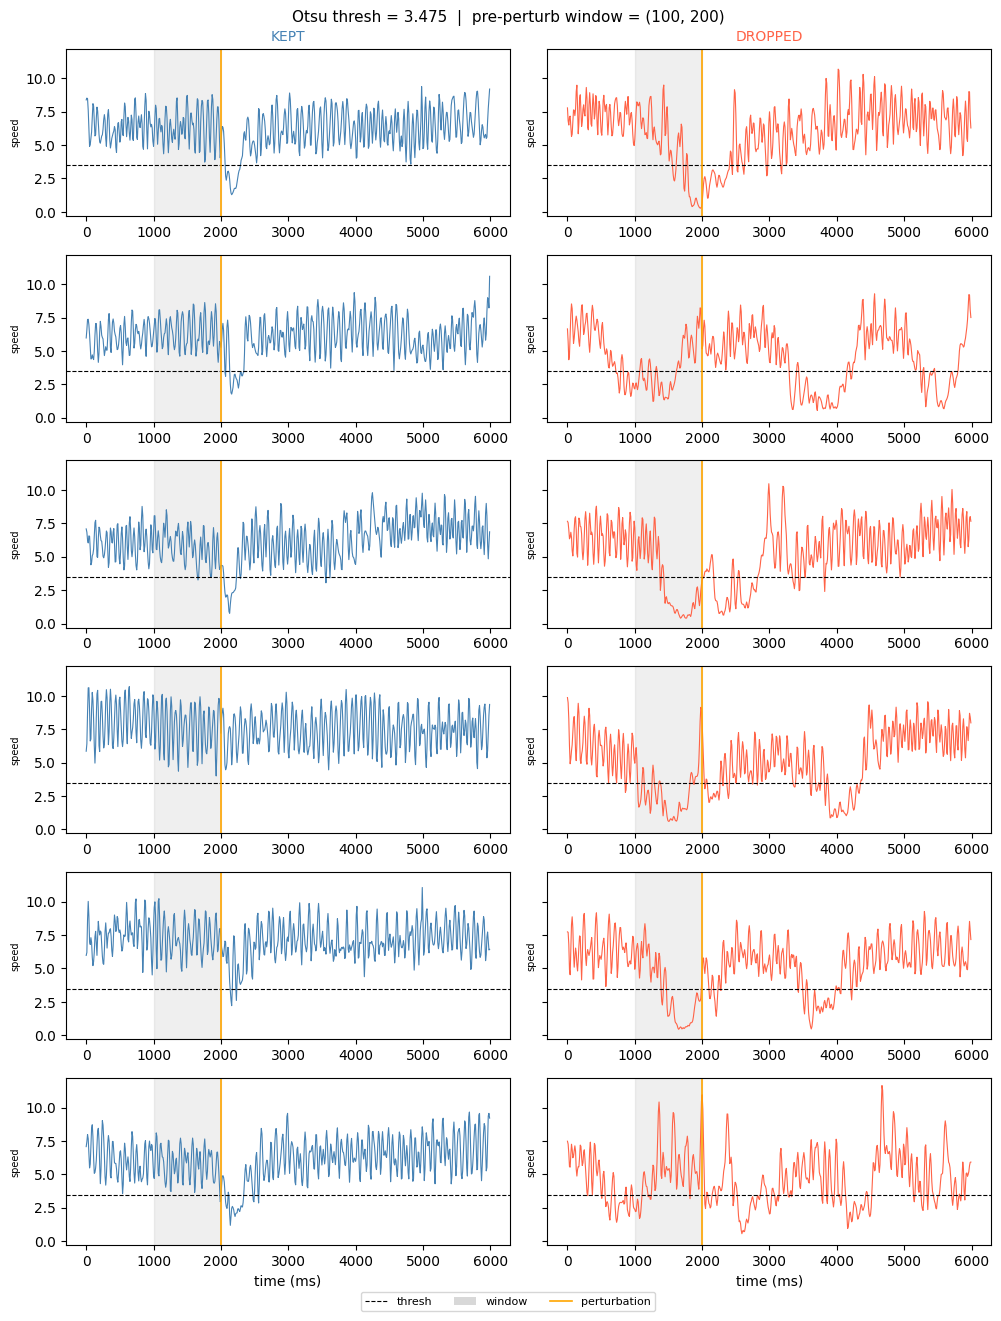

In [45]:
from tools.kinematics.utils import otsu_threshold

def _trial_speed(bhv_arr):
    vel = np.gradient(bhv_arr, axis=0)
    return np.linalg.norm(vel, axis=1)

pooled_log_speed = np.log(np.maximum(
    np.concatenate([_trial_speed(arr) for arr in df_tr.bhv.values]), 1e-10
))
thresh = np.exp(otsu_threshold(pooled_log_speed))

kept_idx = df_tr_dropped.index
dropped_idx = df_tr.index.difference(kept_idx)

PRE_PERTURB_WINDOW = (100, 200)
N_EXAMPLES = 6  # per group

fig, axes = plt.subplots(N_EXAMPLES, 2, figsize=(10, N_EXAMPLES * 2.2), sharex=False, sharey=True)
fig.suptitle(f"Otsu thresh = {thresh:.3f}  |  pre-perturb window = {PRE_PERTURB_WINDOW}", fontsize=11)
axes[0, 0].set_title("KEPT", fontsize=10, color="steelblue")
axes[0, 1].set_title("DROPPED", fontsize=10, color="tomato")

for col, (idx_pool, color) in enumerate([(kept_idx, "steelblue"), (dropped_idx, "tomato")]):
    sample = np.random.choice(idx_pool, size=min(N_EXAMPLES, len(idx_pool)), replace=False)
    for row, idx in enumerate(sample):
        row_data = df_tr.loc[idx]
        speed = _trial_speed(row_data.bhv)
        ax = axes[row, col]
        t = np.arange(len(speed)) * 10
        ax.plot(t, speed, color=color, lw=0.8)
        ax.axhline(thresh, color="k", linestyle="--", lw=0.8)
        ax.axvspan(PRE_PERTURB_WINDOW[0] * 10, PRE_PERTURB_WINDOW[1] * 10, alpha=0.12, color="gray")
        ax.axvline(row_data.idx_sol_on * 10, color="orange", lw=1.2)
        ax.set_ylabel("speed", fontsize=7)
        if row == N_EXAMPLES - 1:
            ax.set_xlabel("time (ms)")

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
handles = [
    Line2D([0], [0], color="k", linestyle="--", lw=0.8, label="thresh"),
    Patch(facecolor="gray", alpha=0.3, label="window"),
    Line2D([0], [0], color="orange", lw=1.2, label="perturbation"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.show()


In [46]:
df_design = df_tr.copy()
idx_to_keep = 200
df_design = df_design.iloc[sorted(dstrb_idx[2:idx_to_keep])]
df_design_ = df_design.sample(frac=1, random_state=42).reset_index(drop=True)

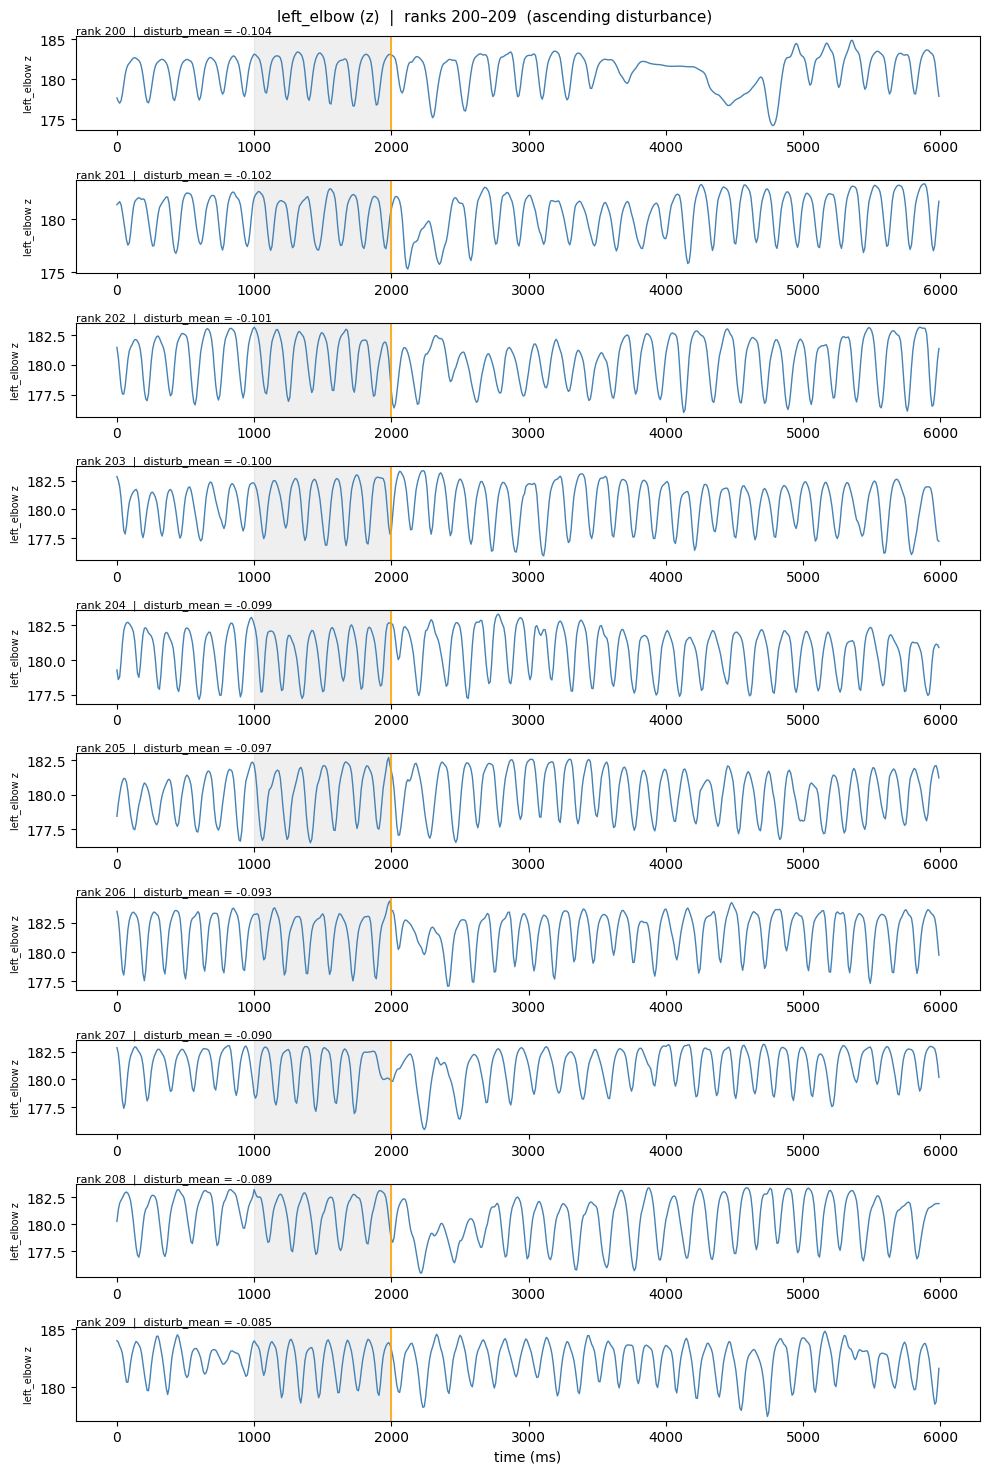

In [67]:
# --- Parameters ---
PAGE = 20
PAGE_SIZE = 10
KEYPOINT = 'left_elbow'   # any name in Params.oscillating_key_points
DIM = 2                   # 0=x, 1=y, 2=z (vertical)
# ------------------

kp_idx = list(Params.oscillating_key_points).index(KEYPOINT)
col_idx = kp_idx * 3 + DIM
dim_label = ['x', 'y', 'z'][DIM]

start = PAGE * PAGE_SIZE
end = start + PAGE_SIZE
trial_indices = dstrb_idx[start:end]

fig, axes = plt.subplots(PAGE_SIZE, 1, figsize=(10, PAGE_SIZE * 1.5), sharex=False)
fig.suptitle(f"{KEYPOINT} ({dim_label})  |  ranks {start}–{end - 1}  (ascending disturbance)", fontsize=11)

for row, idx in enumerate(trial_indices):
    row_data = df_tr.loc[df_tr.index[idx]]
    trace = row_data.bhv[:, col_idx]
    t = np.arange(len(trace)) * 10
    ax = axes[row]
    ax.plot(t, trace, color="steelblue", lw=1)
    ax.axvspan(PRE_PERTURB_WINDOW[0] * 10, PRE_PERTURB_WINDOW[1] * 10, alpha=0.12, color="gray")
    ax.axvline(row_data.idx_sol_on * 10, color="orange", lw=1.2)
    disturb_mean = row_data.disturb_mean if hasattr(row_data, 'disturb_mean') else np.log10(np.abs(np.sum(row_data.disturb_score)))
    ax.set_title(f"rank {start + row}  |  disturb_mean = {disturb_mean:.3f}", fontsize=8, loc="left", pad=2)
    ax.set_ylabel(f"{KEYPOINT} {dim_label}", fontsize=7)
    if row == PAGE_SIZE - 1:
        ax.set_xlabel("time (ms)")

plt.tight_layout()
plt.show()


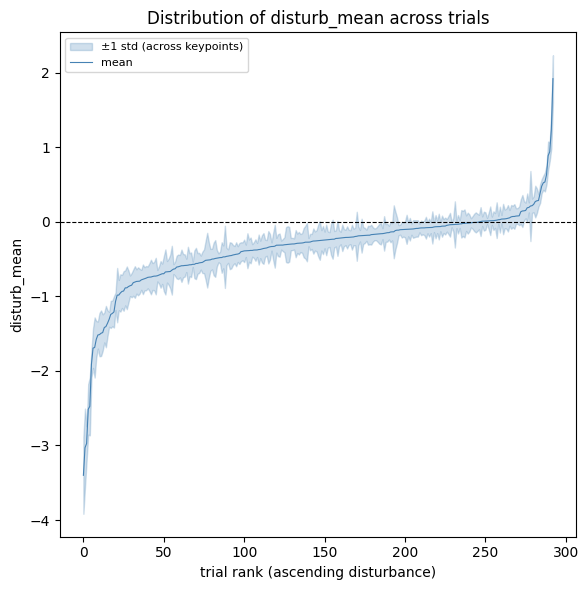

In [70]:
disturb_mean_sorted = df_tr['disturb_mean'].values[dstrb_idx]
disturb_std_sorted = df_tr['disturb_score'].apply(np.std).values[dstrb_idx]

x = np.arange(len(disturb_mean_sorted))
fig, ax = plt.subplots(figsize=(6, 6))
ax.fill_between(x, disturb_mean_sorted - disturb_std_sorted, disturb_mean_sorted + disturb_std_sorted,
                color="steelblue", alpha=0.25, label="±1 std (across keypoints)")
ax.plot(x, disturb_mean_sorted, color="steelblue", lw=0.8, label="mean")
ax.axhline(0, color="k", linestyle="--", lw=0.8)
ax.set_xlabel("trial rank (ascending disturbance)")
ax.set_ylabel("disturb_mean")
ax.set_title("Distribution of disturb_mean across trials")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


# Refactored loading

In [23]:
def load_and_process_session(session, data_dir='/data/raw/', bhv_fields=None, min_immobile_bins=5):
    """
    Full pipeline for a session:
      1. Load raw pyalData
      2. Preprocess (remove low-firing neurons, keep 10 ms bins)
      3. Fit PCA on all rows except the first (free locomotion period)
      4. Compute perturbation metric (bhv_concat, Morlet power, disturb_score)
      5. Filter to perturbation trials, drop immobile, drop NaN scores
      6. Add disturb_mean / disturb_sum and sort by disturbance

    Returns
    -------
    df_tr      : pd.DataFrame  filtered, annotated trial table
    dstrb_idx  : np.ndarray    indices that sort df_tr ascending by disturbance
    """
    if bhv_fields is None:
        bhv_fields = Params.oscillating_key_points

    # 1 & 2 — load + preprocess
    df = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
    df = dsp.preprocess(df, only_trials=False, combine_time_bins=False)

    # 3 — PCA excluding the first row (free locomotion period)
    df = dt.add_pca_df(df.iloc[1:])

    # 4 — perturbation metric
    df = kin.compute_perturbation_metric(df, bhv_fields=bhv_fields)

    # 5 — filter trials
    df_tr = pyal.select_trials(df, df.trial_name == 'trial')
    df_tr = kin.drop_immobile_trials(df_tr, min_immobile_bins=min_immobile_bins)
    mask = df_tr["disturb_score"].apply(
        lambda x: isinstance(x, np.ndarray) and not np.any(np.isnan(x))
    )
    df_tr = df_tr.loc[mask]

    # 6 — derived metrics + sort order
    df_tr['disturb_mean'] = df_tr['disturb_score'].apply(np.mean)
    df_tr['disturb_sum'] = df_tr['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))
    disturbances = np.sum(np.stack(df_tr.disturb_score.values), axis=1)
    dstrb_idx = np.argsort(disturbances)

    return df_tr, dstrb_idx


# df_tr, dstrb_idx = load_and_process_session(session)
# print(f"Trials retained: {len(df_tr)}")


In [84]:
df_design = df_tr.copy()

# Keep trials ranked up to 1 std below 0 in disturbance
disturb_mean_vals = df_tr['disturb_mean'].values
std_disturb = scipy.stats.sem(disturb_mean_vals)
threshold = -std_disturb  # 1 std below 0

disturb_mean_sorted_vals = disturb_mean_vals[dstrb_idx]
idx_to_keep = int(np.searchsorted(disturb_mean_sorted_vals, threshold))

print(f"threshold = {threshold:.3f}  |  trials selected: {idx_to_keep - 2} (ranks {idx_to_keep - 1})")

df_design = df_design.iloc[sorted(dstrb_idx[:idx_to_keep])]
perturb_td = pyal.restrict_to_interval(df_design, start_point_name='idx_sol_on', rel_start=-200, rel_end=300)
perturb_td = dt.add_bhv(perturb_td)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)


threshold = -0.031  |  trials selected: 218 (ranks 219)


In [160]:
def decode_direction_by_area(td, areas, window=20, step=2, k=5, shuffle=False, rnd=None):
    """
    Run moving-window direction decoding (values_Sol_direction) for each area.

    Parameters
    ----------
    td     : pd.DataFrame  trial table restricted to the epoch of interest
    areas  : list[str]     area names (resolved to '{area}_rates_pca') or raw
                           column names (e.g. 'bhv') used directly if the
                           '_rates_pca' variant is absent
    window : int           sliding window length in bins
    step   : int           step size in bins
    k      : int           number of CV folds (StratifiedKFold)

    Returns
    -------
    results : dict  {area: {'scores': ndarray (folds × time), 'times': ndarray}}
    """
    y = np.array(td.values_Sol_direction.values.tolist(), dtype=int)
    cv = StratifiedKFold(n_splits=k, shuffle=shuffle, random_state=rnd)
    results = {}
    for area in areas:
        pca_label = f"{area}_rates_pca"
        if pca_label in td.columns:
            label = pca_label
        elif area in td.columns:
            label = area
        else:
            print(f"  {area}: no column '{pca_label}' or '{area}' found, skipping")
            continue
        X = np.stack(td[label].values)
        scores, times = decode.moving_window_decoding(
            X, y, cv=cv, window_length_bin=window, step_bin=step
        )
        results[area] = {"scores": scores, "times": times}
        print(f"  {area}: done  (mean acc = {np.mean(scores):.3f})")
    return results


# --- Run ---
# AREAS = ['MOp', 'SSp', 'CP', 'VAL', 'bhv']

# # Majority-class chance: honest baseline when directions are imbalanced after
# # disturbance-based trial selection (some directions cause more disruption).
# y_all = np.array(perturb_td_shuff.values_Sol_direction.values.tolist(), dtype=int)
# CHANCE = np.max(np.bincount(y_all)) / len(y_all)
# print(f"Uniform chance = {1/12:.3f}  |  majority-class chance = {CHANCE:.3f}")
# print(f"Direction counts: {np.bincount(y_all)}")

# results = decode_direction_by_area(perturb_td_shuff, AREAS, step=1)


In [171]:
def plot_decoding_by_area(results, areas, chance=None, peak_lags=None):
    """Plot mean ± SEM decoding curves (left) and per-fold CoM summary (right)."""
    show_com = peak_lags is not None and any(
        "com_folds" in peak_lags.get(a, {}) for a in areas
    )
    if show_com:
        fig, (ax, ax_com) = plt.subplots(
            1, 2, figsize=(10, 8), gridspec_kw={"width_ratios": [3, 1]}
        )
    else:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax_com = None

    for area in areas:
        if area not in results:
            continue
        scores = results[area]["scores"]
        times  = results[area]["times"]
        color = getattr(colors, f'{area}_light', None)
        vizutils.shaded_errorbar(ax, times - 2, scores, color=color, label=area)

    if chance is not None:
        ax.axhline(chance, color="k", linestyle="dashed", label="chance")
    ax.axvline(0, color="gray", linestyle="dashed", label="perturb")

    # peak-lag dots at the top
    if peak_lags is not None:
        y_top = ax.get_ylim()[1]
        dot_y = y_top * 0.97
        for area in areas:
            if area not in peak_lags:
                continue
            color = getattr(colors, f'{area}_light')
            ax.scatter(peak_lags[area]["peak"], dot_y, color=color,
                       s=80, zorder=5, clip_on=False)

    ax.set_xlabel("Time rel. perturb. (s)")
    ax.set_ylabel("Decoding Accuracy (%)")
    ax.set_title("Direction decoding by area")
    ax.legend(frameon=False)

    # CoM subplot
    if show_com and ax_com is not None:
        present = [a for a in areas if a in peak_lags and "com_folds" in peak_lags[a]]
        x_pos = np.arange(len(present))
        for i, area in enumerate(present):
            c = getattr(colors, area, "steelblue")
            mean  = peak_lags[area]["com_mean"]
            std   = peak_lags[area]["com_std"]
            folds = peak_lags[area]["com_folds"]
            ax_com.scatter(np.full_like(folds, i, dtype=float), folds,
                           color=c, alpha=0.4, s=25, zorder=3)
            ax_com.errorbar(i, mean, yerr=std, fmt="o", color=c,
                            capsize=4, capthick=1.5, ms=7, zorder=4)
        ax_com.axhline(0, color="gray", linestyle=":", lw=0.8)
        ax_com.set_xticks(x_pos)
        ax_com.set_xticklabels(present, rotation=45, ha="right")
        ax_com.set_ylabel("CoM lag (s)")
        ax_com.set_title("CoM per fold")

    plt.tight_layout()
    return fig, ax


# with vizutils.apply_plot_style():
#     fig, ax = plot_decoding_by_area(results, AREAS, chance=CHANCE)
#     ax.set_xlim(-0.5, 1.2)
# plt.show()


In [167]:
from scipy.ndimage import uniform_filter1d

SMOOTH_BINS = 5   # smoothing kernel width in bins
TIME_OFFSET = 2   # same shift applied in plot_decoding_by_area (times - 2)


def compute_peak_lags(results, chance, smooth_bins=SMOOTH_BINS, time_offset=TIME_OFFSET):
    """
    For each area compute two lag estimates.
    times are shifted by time_offset to match the plot x-axis.

    acc_max      : peak decoding accuracy of the smoothed mean curve
    peak_lag     : argmax of the smoothed mean curve
    com_lag      : CoM of above-chance area on the smoothed mean curve
    com_per_fold : CoM computed independently per fold → mean ± std reported
    """
    lags = {}
    for area, res in results.items():
        scores = res["scores"]   # (time × folds)
        times  = res["times"] - time_offset

        mean_curve = np.mean(scores, axis=1)
        smoothed   = uniform_filter1d(mean_curve, size=smooth_bins)

        # peak of smoothed mean
        peak_lag = times[np.argmax(smoothed)]
        acc_max  = float(np.max(smoothed))

        # CoM of smoothed mean
        above = np.maximum(smoothed - chance, 0.0)
        total = above.sum()
        com_lag = (above * times).sum() / total if total > 0 else np.nan

        # per-fold CoM
        n_folds = scores.shape[1]
        fold_coms = []
        for f in range(n_folds):
            fold_smooth = uniform_filter1d(scores[:, f], size=smooth_bins)
            above_f = np.maximum(fold_smooth - chance, 0.0)
            tot_f = above_f.sum()
            fold_coms.append((above_f * times).sum() / tot_f if tot_f > 0 else np.nan)
        fold_coms = np.array(fold_coms)

        lags[area] = {
            "peak": peak_lag,
            "acc_max": acc_max,
            "com": com_lag,
            "com_folds": fold_coms,
            "com_mean": np.nanmean(fold_coms),
            "com_std":  np.nanstd(fold_coms),
        }
        print(f"  {area:6s}  peak = {peak_lag:+.3f} s   acc_max = {acc_max:.3f}   CoM = {com_lag:+.3f} s  "
              f"(fold CoM: {np.nanmean(fold_coms):+.3f} ± {np.nanstd(fold_coms):.3f} s)")
    return lags


# peak_lags = compute_peak_lags(results, CHANCE)

# # Re-plot curves with peak-lag dots + CoM subplot
# with vizutils.apply_plot_style():
#     fig, ax = plot_decoding_by_area(results, AREAS, chance=CHANCE, peak_lags=peak_lags)
#     ax.set_xlim(-0.5, 1.2)
# plt.show()


In [148]:
peak_lags['MOp']

{'peak': 0.2400000000000002,
 'r2_max': 0.4127272727272729,
 'com': 0.29318369344801143,
 'com_folds': array([0.48056697, 0.16312593, 0.36614893, 0.30456773, 0.45506288]),
 'com_mean': 0.3538944878903389,
 'com_std': 0.11424264077635173}

# Run on all sessions

In [ ]:
sessions = [
    # 'M061_2025_03_04_10_00', 
    # 'M061_2025_03_05_14_00', 
    # 'M061_2025_03_06_14_00',
    # 'M063_2025_03_13_14_00',
    'M063_2025_03_14_15_30', 
    'M062_2025_03_20_14_00',
    # 'M062_2025_03_21_14_00',
    # 'M063_2025_03_14_15_30',
    # 'M078_2025_08_06_15_00',
    # 'M086_2025_12_10_15_00'
]

In [ ]:

# --- Step 1: Load & preprocess all sessions into intermediate dict ---
all_session_processed = {}  # {session: {'td': perturb_td_shuff, 'chance': float} or None}

for sess in tqdm(sessions, desc="Loading sessions"):
    print(f"\n{'='*60}\n{sess}\n{'='*60}")
    try:
        df_tr_s, dstrb_idx_s = load_and_process_session(sess)

        disturb_mean_vals_s = df_tr_s['disturb_mean'].values
        threshold_s = -scipy.stats.sem(disturb_mean_vals_s)
        disturb_mean_sorted_s = disturb_mean_vals_s[dstrb_idx_s]
        idx_to_keep_s = int(np.searchsorted(disturb_mean_sorted_s, threshold_s))
        print(f"  threshold = {threshold_s:.3f}  |  trials selected: {idx_to_keep_s}")

        df_design_s = df_tr_s.iloc[sorted(dstrb_idx_s[:idx_to_keep_s])]
        perturb_td_s = pyal.restrict_to_interval(
            df_design_s, start_point_name='idx_sol_on', rel_start=-200, rel_end=300
        )
        perturb_td_s = dt.add_bhv(perturb_td_s)
        perturb_td_shuff_s = perturb_td_s.sample(frac=1, random_state=42).reset_index(drop=False)

        y_s = np.array(perturb_td_shuff_s.values_Sol_direction.values.tolist(), dtype=int)
        chance_s = np.max(np.bincount(y_s)) / len(y_s)
        print(f"  chance = {chance_s:.3f}  |  n_trials = {len(perturb_td_shuff_s)}")

        all_session_processed[sess] = {'td': perturb_td_shuff_s, 'chance': chance_s}

    except Exception as e:
        import traceback
        print(f"  ERROR loading {sess}: {e}")
        traceback.print_exc()
        all_session_processed[sess] = None

print(f"\nLoaded {sum(v is not None for v in all_session_processed.values())}/{len(sessions)} sessions successfully.")


Loading sessions:   0%|          | 0/1 [00:00<?, ?it/s]


M063_2025_03_14_15_30
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['idx_motion', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['idx_motion', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['VAL_spikes', 'SSp_spikes', 'all_spikes', 'CP_spikes', 'MOp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85228951255539% of trials
  warnings.warn(


Resulting VAL_spikes ephys data shape is (NxT): (260, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (92, 60000)
Resulting all_spikes ephys data shape is (NxT): (38, 60000)
Resulting CP_spikes ephys data shape is (NxT): (329, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (161, 60000)


Traceback (most recent call last):
  File "/home/me24/.cache/pypoetry/virtualenvs/earthquake-analysis-Z8riI-lB-py3.13/lib/python3.13/site-packages/pandas/core/indexes/base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7081, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7089, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'right_knee'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/tmp/ipykernel_827571/1600842936.py", line 7, in <module>
    df_tr_s, dstrb_idx_s = load_and_process_session(sess)
                           ~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "/tmp/ipykernel_827571/

  ERROR loading M063_2025_03_14_15_30: 'right_knee'

Loaded 1/1 sessions successfully.


Decoding sessions:   0%|          | 0/2 [00:00<?, ?it/s]


M061_2025_03_05_14_00


100%|██████████| 482/482 [00:11<00:00, 42.91it/s]


  MOp: done  (mean acc = 0.109)


100%|██████████| 482/482 [00:10<00:00, 47.69it/s]


...

  CP: done  (mean acc = 0.112)


100%|██████████| 482/482 [00:13<00:00, 35.90it/s]


  VAL: done  (mean acc = 0.103)


100%|██████████| 482/482 [00:08<00:00, 57.67it/s]


  bhv: done  (mean acc = 0.114)
  MOp     peak = +0.250 s   acc_max = 0.330   CoM = +0.334 s  (fold CoM: +0.423 ± 0.240 s)
  SSp     peak = +0.280 s   acc_max = 0.258   CoM = +0.593 s  (fold CoM: +0.780 ± 0.204 s)
  CP      peak = +0.340 s   acc_max = 0.368   CoM = +0.221 s  (fold CoM: +0.371 ± 0.257 s)
  VAL     peak = +0.290 s   acc_max = 0.201   CoM = +0.062 s  (fold CoM: +0.354 ± 0.313 s)
  bhv     peak = +0.230 s   acc_max = 0.377   CoM = +0.426 s  (fold CoM: +0.398 ± 0.216 s)


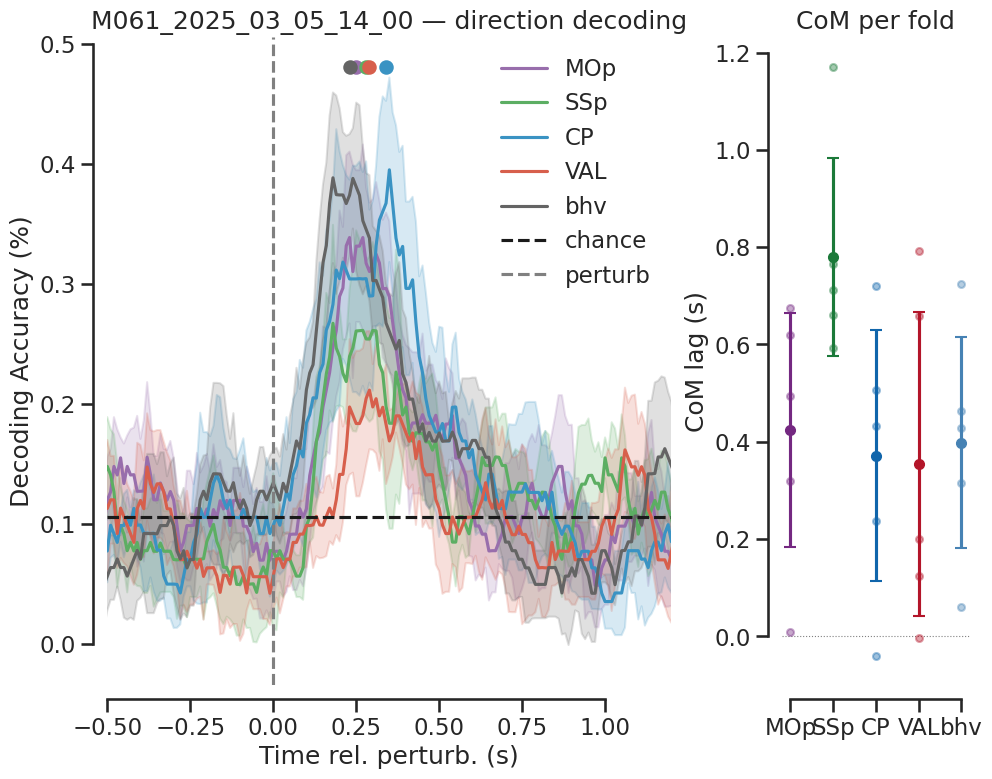

Decoding sessions:  50%|█████     | 1/2 [00:55<00:55, 55.79s/it]


M061_2025_03_06_14_00


100%|██████████| 482/482 [00:14<00:00, 32.88it/s]


  MOp: done  (mean acc = 0.135)


100%|██████████| 482/482 [00:08<00:00, 54.80it/s]


...

  CP: done  (mean acc = 0.130)


100%|██████████| 482/482 [00:13<00:00, 34.71it/s]


  VAL: done  (mean acc = 0.127)


100%|██████████| 482/482 [00:08<00:00, 57.23it/s]


  bhv: done  (mean acc = 0.121)
  MOp     peak = +0.240 s   acc_max = 0.413   CoM = +0.293 s  (fold CoM: +0.354 ± 0.114 s)
  SSp     peak = +0.240 s   acc_max = 0.284   CoM = +0.304 s  (fold CoM: +0.238 ± 0.229 s)
  CP      peak = +0.320 s   acc_max = 0.325   CoM = +0.291 s  (fold CoM: +0.405 ± 0.326 s)
  VAL     peak = +0.450 s   acc_max = 0.330   CoM = +0.489 s  (fold CoM: +0.524 ± 0.085 s)
  bhv     peak = +0.250 s   acc_max = 0.463   CoM = +0.291 s  (fold CoM: +0.420 ± 0.112 s)


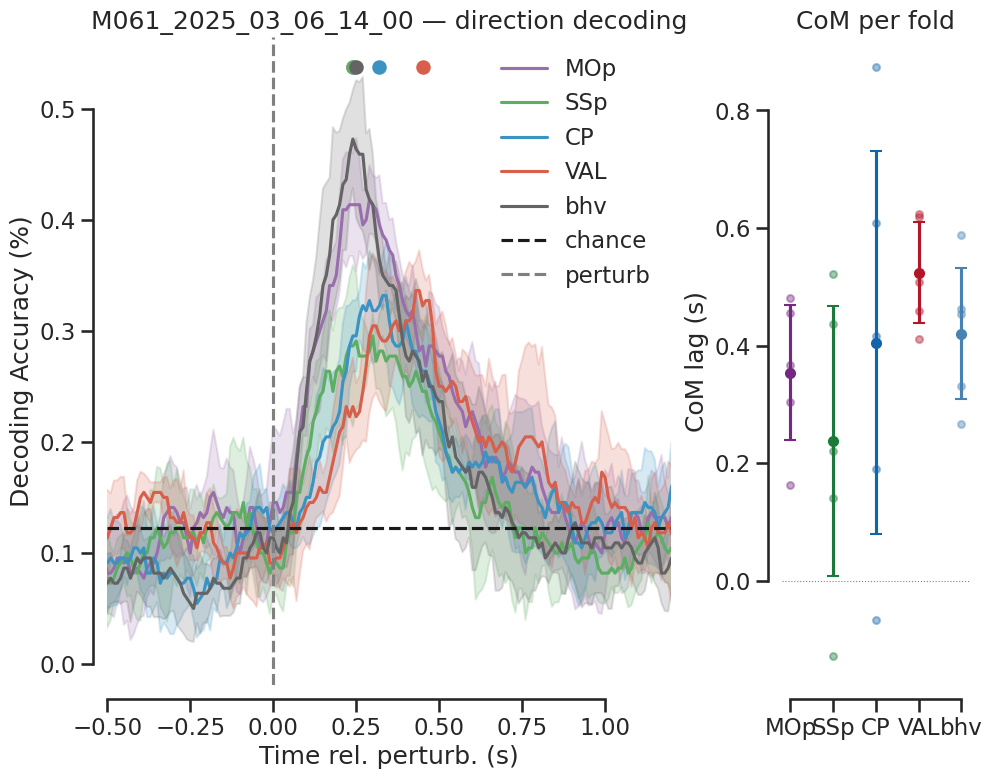

Decoding sessions: 100%|██████████| 2/2 [01:56<00:00, 58.01s/it]


--- Summary ---
  M061_2025_03_05_14_00  →  MOp: acc_max=0.330  peak=+0.250s  CoM=+0.423s  SSp: acc_max=0.258  peak=+0.280s  CoM=+0.780s  CP: acc_max=0.368  peak=+0.340s  CoM=+0.371s  VAL: acc_max=0.201  peak=+0.290s  CoM=+0.354s  bhv: acc_max=0.377  peak=+0.230s  CoM=+0.398s
  M061_2025_03_06_14_00  →  MOp: acc_max=0.413  peak=+0.240s  CoM=+0.354s  SSp: acc_max=0.284  peak=+0.240s  CoM=+0.238s  CP: acc_max=0.325  peak=+0.320s  CoM=+0.405s  VAL: acc_max=0.330  peak=+0.450s  CoM=+0.524s  bhv: acc_max=0.463  peak=+0.250s  CoM=+0.420s


In [172]:

# --- Step 2: Decode each session + diagnostic plot ---
all_session_lags = {}  # {session: {area: {'acc_max': float, 'peak': float, 'com_mean': float}}}

for sess, proc in tqdm(all_session_processed.items(), desc="Decoding sessions"):
    if proc is None:
        all_session_lags[sess] = None
        continue
    print(f"\n{'='*60}\n{sess}\n{'='*60}")
    try:
        td       = proc['td']
        chance_s = proc['chance']

        results_s = decode_direction_by_area(td, AREAS, step=1)
        lags_s    = compute_peak_lags(results_s, chance_s)

        # Diagnostic: time vs accuracy curves for this session
        with vizutils.apply_plot_style():
            fig, ax = plot_decoding_by_area(results_s, AREAS, chance=chance_s, peak_lags=lags_s)
            ax.set_xlim(-0.5, 1.2)
            ax.set_title(f"{sess} — direction decoding")
        plt.show()

        all_session_lags[sess] = {
            area: {
                'acc_max':  info['acc_max'],
                'peak':     info['peak'],
                'com_mean': info['com_mean'],
            }
            for area, info in lags_s.items()
        }

    except Exception as e:
        import traceback
        print(f"  ERROR decoding {sess}: {e}")
        traceback.print_exc()
        all_session_lags[sess] = None

print("\n--- Summary ---")
for s, lags in all_session_lags.items():
    if lags is not None:
        lag_str = "  ".join(
            f"{a}: acc_max={v['acc_max']:.3f}  peak={v['peak']:+.3f}s  CoM={v['com_mean']:+.3f}s"
            for a, v in lags.items()
        )
        print(f"  {s}  →  {lag_str}")
    else:
        print(f"  {s}  →  FAILED")


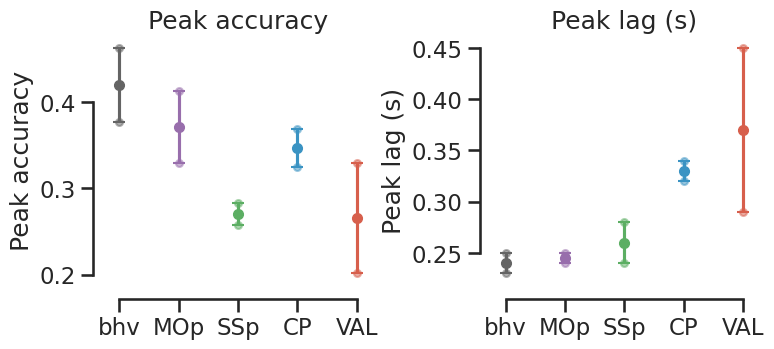

In [174]:

# --- Aggregate across sessions ---
metrics = ['acc_max', 'peak']
metric_labels = ['Peak accuracy', 'Peak lag (s)']
PLOT_ORDER = ['bhv', 'MOp', 'SSp', 'CP', 'VAL']

# Build {area: {metric: [values across sessions]}}
agg = {area: {m: [] for m in metrics} for area in PLOT_ORDER}
for sess_lags in all_session_lags.values():
    if sess_lags is None:
        continue
    for area in PLOT_ORDER:
        if area not in sess_lags:
            continue
        for m in metrics:
            agg[area][m].append(sess_lags[area][m])

# --- Plot ---
with vizutils.apply_plot_style():
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    for ax, metric, ylabel in zip(axes, metrics, metric_labels):
        present = [a for a in PLOT_ORDER if len(agg[a][metric]) > 0]
        x_pos = np.arange(len(present))

        for i, area in enumerate(present):
            vals = np.array(agg[area][metric])
            mean = np.nanmean(vals)
            std  = np.nanstd(vals)
            c = getattr(colors, f'{area}_light', getattr(colors, area, 'steelblue'))

            ax.scatter(np.full(len(vals), i), vals, color=c, alpha=0.5, s=25, zorder=3)
            ax.errorbar(i, mean, yerr=std, fmt='o', color=c,
                        capsize=4, capthick=1.5, ms=7, zorder=4)

        # if metric == 'peak':
        #     ax.axhline(0, color='gray', linestyle=':', lw=0.8)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(present, rotation=45, ha='right')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)

    plt.tight_layout()
plt.show()
